In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import pandas as pd
import numpy as np

print("Pandas and NumPy ready!")

Pandas and NumPy ready!


In [ ]:
df = pd.read_csv('/ONINE_FOOD_DELIVERY_ANALYSIS.csv')

print("Dataset loaded successfully!")
print("Rows and Columns:", df.shape)

df.head()

Dataset loaded successfully!
Rows and Columns: (100000, 25)


,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,...,Final_Amount,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin
0,ORD000001,CUST6948,19.0,Male,NaN,Central,RES936,Restaurant_29,Chinese,10/20/2024,...,NaN,UPI,Delivered,NaN,DP563,5.0,4.4,Weekend,True,0.13
1,ORD000002,CUST6515,NaN,Female,Chennai,North,RES689,Restaurant_419,Chinese,8/12/2024,...,4849.0,COD,Delivered,NaN,DP369,5.0,4.7,Weekday,True,0.48
2,ORD000003,CUST1765,NaN,Male,Delhi,NaN,RES723,Restaurant_244,Arabian,12/8/2024,...,737.0,Wallet,Delivered,NaN,DP580,4.0,4.9,Weekend,True,0.08
3,ORD000004,CUST2744,NaN,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,10/8/2024,...,NaN,UPI,Cancelled,Late Delivery,DP155,2.0,3.4,Weekday,NaN,0.04
4,ORD000005,CUST4389,57.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2/4/2024,...,352.0,Card,Delivered,NaN,DP728,2.0,4.4,Weekend,False,0.12


In [ ]:
print("Total Rows:", df.shape[0])
print("Total Columns:", df.shape[1])

print("\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(i, col)

Total Rows: 100000
Total Columns: 25

Column Names:
1 Order_ID
2 Customer_ID
3 Customer_Age
4 Customer_Gender
5 City
6 Area
7 Restaurant_ID
8 Restaurant_Name
9 Cuisine_Type
10 Order_Date
11 Order_Time
12 Delivery_Time_Min
13 Distance_km
14 Order_Value
15 Discount_Applied
16 Final_Amount
17 Payment_Mode
18 Order_Status
19 Cancellation_Reason
20 Delivery_Partner_ID
21 Delivery_Rating
22 Restaurant_Rating
23 Order_Day
24 Peak_Hour
25 Profit_Margin


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Order_ID             100000 non-null  object 
 1   Customer_ID          100000 non-null  object 
 2   Customer_Age         49907 non-null   float64
 3   Customer_Gender      75144 non-null   object 
 4   City                 83274 non-null   object 
 5   Area                 83315 non-null   object 
 6   Restaurant_ID        100000 non-null  object 
 7   Restaurant_Name      100000 non-null  object 
 8   Cuisine_Type         83115 non-null   object 
 9   Order_Date           98986 non-null   object 
 10  Order_Time           98002 non-null   object 
 11  Delivery_Time_Min    66641 non-null   float64
 12  Distance_km          66530 non-null   float64
 13  Order_Value          66673 non-null   float64
 14  Discount_Applied     83285 non-null   float64
 15  Final_Amount      

In [ ]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
Order_ID                   0
Customer_ID                0
Customer_Age           50093
Customer_Gender        24856
City                   16726
Area                   16685
Restaurant_ID              0
Restaurant_Name            0
Cuisine_Type           16885
Order_Date              1014
Order_Time              1998
Delivery_Time_Min      33359
Distance_km            33470
Order_Value            33327
Discount_Applied       16715
Final_Amount           55697
Payment_Mode           19911
Order_Status               0
Cancellation_Reason    90969
Delivery_Partner_ID        0
Delivery_Rating        16523
Restaurant_Rating          0
Order_Day                  0
Peak_Hour              32962
Profit_Margin              0
dtype: int64


In [ ]:
duplicate_count = df.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 0


In [ ]:
df = df.drop_duplicates()

print("Duplicates removed!")
print("Current dataset shape:", df.shape)

Duplicates removed!
Current dataset shape: (100000, 25)


In [ ]:
numeric_columns = [
    'Customer_Age',
    'Delivery_Time_Min',
    'Distance_km',
    'Order_Value',
    'Final_Amount',
    'Delivery_Rating'
]

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

print("Numerical missing values filled successfully!")

print(df[numeric_columns].isnull().sum())

Numerical missing values filled successfully!
Customer_Age         0
Delivery_Time_Min    0
Distance_km          0
Order_Value          0
Final_Amount         0
Delivery_Rating      0
dtype: int64


In [ ]:
categorical_columns = [
    'Customer_Gender',
    'City',
    'Area',
    'Cuisine_Type',
    'Payment_Mode',
    'Peak_Hour'
]

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Categorical missing values filled successfully!")

print(df[categorical_columns].isnull().sum())

Categorical missing values filled successfully!
Customer_Gender    0
City               0
Area               0
Cuisine_Type       0
Payment_Mode       0
Peak_Hour          0
dtype: int64


/tmp/ipykernel_1824/4231451794.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [ ]:
# Date and Time missing values
df['Order_Date'] = df['Order_Date'].fillna(df['Order_Date'].mode()[0])
df['Order_Time'] = df['Order_Time'].fillna(df['Order_Time'].mode()[0])

# Discount missing என்றால் No Discount என்று எடுத்துக்கொள்வோம்
df['Discount_Applied'] = df['Discount_Applied'].fillna('No')

# Cancellation reason
df['Cancellation_Reason'] = df['Cancellation_Reason'].fillna('Not Cancelled')

print("Remaining missing values handled!")

print(df.isnull().sum())

Remaining missing values handled!
Order_ID               0
Customer_ID            0
Customer_Age           0
Customer_Gender        0
City                   0
Area                   0
Restaurant_ID          0
Restaurant_Name        0
Cuisine_Type           0
Order_Date             0
Order_Time             0
Delivery_Time_Min      0
Distance_km            0
Order_Value            0
Discount_Applied       0
Final_Amount           0
Payment_Mode           0
Order_Status           0
Cancellation_Reason    0
Delivery_Partner_ID    0
Delivery_Rating        0
Restaurant_Rating      0
Order_Day              0
Peak_Hour              0
Profit_Margin          0
dtype: int64


In [ ]:
print(df.columns.tolist())

['Order_ID', 'Customer_ID', 'Customer_Age', 'Customer_Gender', 'City', 'Area', 'Restaurant_ID', 'Restaurant_Name', 'Cuisine_Type', 'Order_Date', 'Order_Time', 'Delivery_Time_Min', 'Distance_km', 'Order_Value', 'Discount_Applied', 'Final_Amount', 'Payment_Mode', 'Order_Status', 'Cancellation_Reason', 'Delivery_Partner_ID', 'Delivery_Rating', 'Restaurant_Rating', 'Order_Day', 'Peak_Hour', 'Profit_Margin']


In [ ]:
print("Delivery Rating > 5:",
      (df['Delivery_Rating'] > 5).sum())

print("Restaurant Rating > 5:",
      (df['Restaurant_Rating'] > 5).sum())

print("Negative Profit Margin:",
      (df['Profit_Margin'] < 0).sum())

Delivery Rating > 5: 0
Restaurant Rating > 5: 18019
Negative Profit Margin: 27733


In [ ]:
# Ratings should stay between 0 and 5
df['Delivery_Rating'] = df['Delivery_Rating'].clip(0, 5)
df['Restaurant_Rating'] = df['Restaurant_Rating'].clip(0, 5)

# Profit margin should not be negative
df['Profit_Margin'] = df['Profit_Margin'].clip(lower=0)

print("Invalid values corrected!")

print("Delivery Rating > 5:", (df['Delivery_Rating'] > 5).sum())
print("Restaurant Rating > 5:", (df['Restaurant_Rating'] > 5).sum())
print("Negative Profit Margin:", (df['Profit_Margin'] < 0).sum())

Invalid values corrected!
Delivery Rating > 5: 0
Restaurant Rating > 5: 0
Negative Profit Margin: 0


In [ ]:
print("Delivery Time:")
print(df['Delivery_Time_Min'].describe())

print("\nOrder Value:")
print(df['Order_Value'].describe())

Delivery Time:
count    100000.000000
mean        124.982030
std          74.211956
min          20.000000
25%          58.000000
50%         120.000000
75%         165.000000
max         300.000000
Name: Delivery_Time_Min, dtype: float64

Order Value:
count    100000.00000
mean       1786.94279
std        1335.39821
min         150.00000
25%         935.00000
50%        1197.00000
75%        2743.00000
max        5000.00000
Name: Order_Value, dtype: float64


In [ ]:
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df[column] = df[column].clip(lower_limit, upper_limit)

    print(column)
    print("Lower Limit:", lower_limit)
    print("Upper Limit:", upper_limit)


cap_outliers(df, 'Delivery_Time_Min')
cap_outliers(df, 'Order_Value')

Delivery_Time_Min
Lower Limit: -102.5
Upper Limit: 325.5
Order_Value
Lower Limit: -1777.0
Upper Limit: 5455.0


In [ ]:
df['Order_Date'] = pd.to_datetime(
    df['Order_Date'],
    errors='coerce'
)

print(df['Order_Date'].head())
print("Date datatype:", df['Order_Date'].dtype)

0   2024-10-20
1   2024-08-12
2   2024-12-08
3   2024-10-08
4   2024-02-04
Name: Order_Date, dtype: datetime64[ns]
Date datatype: datetime64[ns]


In [ ]:
df['Order_Day_Type'] = df['Order_Date'].dt.dayofweek.apply(
    lambda x: 'Weekend' if x >= 5 else 'Weekday'
)

print(df[['Order_Date', 'Order_Day_Type']].head(10))

  Order_Date Order_Day_Type
0 2024-10-20        Weekend
1 2024-08-12        Weekday
2 2024-12-08        Weekend
3 2024-10-08        Weekday
4 2024-02-04        Weekend
5 2024-07-09        Weekday
6 2024-02-14        Weekday
7 2024-05-26        Weekend
8 2024-09-07        Weekend
9 2024-01-22        Weekday


In [ ]:
bins = [0, 20, 30, 40, 50, 60, 100]
labels = ['Below 20', '21-30', '31-40', '41-50', '51-60', 'Above 60']

df['Age_Group'] = pd.cut(
    df['Customer_Age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print(df[['Customer_Age', 'Age_Group']].head(10))

   Customer_Age Age_Group
0          19.0  Below 20
1          39.0     31-40
2          39.0     31-40
3          39.0     31-40
4          57.0     51-60
5          37.0     31-40
6          40.0     31-40
7          39.0     31-40
8          39.0     31-40
9          39.0     31-40


In [ ]:
def delivery_category(time):
    if time <= 30:
        return 'Fast'
    elif time <= 60:
        return 'Normal'
    elif time <= 120:
        return 'Slow'
    else:
        return 'Very Slow'

df['Delivery_Performance'] = df['Delivery_Time_Min'].apply(delivery_category)

print(df[['Delivery_Time_Min', 'Delivery_Performance']].head(10))

   Delivery_Time_Min Delivery_Performance
0              187.0            Very Slow
1               20.0                 Fast
2              207.0            Very Slow
3              143.0            Very Slow
4               51.0               Normal
5               56.0               Normal
6              273.0            Very Slow
7              120.0                 Slow
8              120.0                 Slow
9              120.0                 Slow


In [ ]:
print("Peak Hour Values:")
print(df['Peak_Hour'].value_counts(dropna=False))

Peak Hour Values:
Peak_Hour
False    66547
True     33453
Name: count, dtype: int64


In [ ]:
print(df['Profit_Margin'].describe())

print("\nSample Values:")
print(df[['Order_Value', 'Final_Amount', 'Profit_Margin']].head(10))

count    100000.000000
mean          0.178838
std           0.166049
min           0.000000
25%           0.000000
50%           0.150000
75%           0.320000
max           0.500000
Name: Profit_Margin, dtype: float64

Sample Values:
   Order_Value  Final_Amount  Profit_Margin
0       1197.0        1156.0           0.13
1       4869.0        4849.0           0.48
2        757.0         737.0           0.08
3       1197.0        1156.0           0.04
4        372.0         352.0           0.12
5       1197.0        1156.0           0.24
6       1197.0        1156.0           0.02
7       3506.0        3486.0           0.18
8        525.0         425.0           0.08
9       4691.0        4641.0           0.03


In [ ]:
print("Dataset Shape:", df.shape)
print("Duplicate Rows:", df.duplicated().sum())
print("Total Missing Values:", df.isnull().sum().sum())

print("\nNew Columns:")
print(df[['Order_Day_Type',
          'Age_Group',
          'Delivery_Performance']].head())

print("\nCleaning & Feature Engineering Completed!")

Dataset Shape: (100000, 28)
Duplicate Rows: 0
Total Missing Values: 0

New Columns:
  Order_Day_Type Age_Group Delivery_Performance
0        Weekend  Below 20            Very Slow
1        Weekday     31-40                 Fast
2        Weekend     31-40            Very Slow
3        Weekday     31-40            Very Slow
4        Weekend     51-60               Normal

Cleaning & Feature Engineering Completed!


In [ ]:
top_customers = (
    df.groupby('Customer_ID')['Final_Amount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print("Top 10 Spending Customers:")
print(top_customers)

Top 10 Spending Customers:
Customer_ID
CUST3471    44379.0
CUST4431    43825.0
CUST1968    42407.0
CUST6252    42207.0
CUST1606    42185.0
CUST9591    40813.0
CUST8122    40065.0
CUST5409    40046.0
CUST8524    39999.0
CUST8797    39757.0
Name: Final_Amount, dtype: float64


In [ ]:
age_order_analysis = (
    df.groupby('Age_Group', observed=True)['Order_Value']
      .mean()
      .sort_values(ascending=False)
)

print("Average Order Value by Age Group:")
print(age_order_analysis)

Average Order Value by Age Group:
Age_Group
21-30       1794.734541
41-50       1788.778872
Below 20    1786.186441
31-40       1785.610662
51-60       1784.602071
Name: Order_Value, dtype: float64


In [ ]:
day_pattern = df.groupby('Order_Day_Type').agg(
    Total_Orders=('Order_ID', 'count'),
    Average_Order_Value=('Order_Value', 'mean'),
    Total_Revenue=('Final_Amount', 'sum')
)

print("Weekend vs Weekday Order Pattern:")
print(day_pattern)

Weekend vs Weekday Order Pattern:
                Total_Orders  Average_Order_Value  Total_Revenue
Order_Day_Type                                                  
Weekday                71632          1789.488971    108485967.0
Weekend                28368          1780.513431     42782431.0


In [ ]:
df['Order_Month'] = df['Order_Date'].dt.to_period('M').astype(str)

monthly_revenue = (
    df.groupby('Order_Month')['Final_Amount']
      .sum()
      .sort_index()
)

print("Monthly Revenue Trend:")
print(monthly_revenue)

Monthly Revenue Trend:
Order_Month
2024-01    12782792.0
2024-02    11867552.0
2024-03    12546352.0
2024-04    12285333.0
2024-05    12722431.0
2024-06    12486665.0
2024-07    14590655.0
2024-08    12483141.0
2024-09    12477088.0
2024-10    12526182.0
2024-11    12392000.0
2024-12    12108207.0
Name: Final_Amount, dtype: float64


In [ ]:
discount_profit = df.groupby('Discount_Applied').agg(
    Total_Orders=('Order_ID', 'count'),
    Average_Profit_Margin=('Profit_Margin', 'mean'),
    Total_Revenue=('Final_Amount', 'sum')
)

print("Impact of Discounts on Profit:")
print(discount_profit)

Impact of Discounts on Profit:
                  Total_Orders  Average_Profit_Margin  Total_Revenue
Discount_Applied                                                    
0.0                      16650               0.178904     19247400.0
20.0                     16569               0.177937     28996889.0
50.0                     16690               0.177609     28949522.0
100.0                    16776               0.180167     28612350.0
300.0                    16600               0.180608     26139697.0
No                       16715               0.177801     19322540.0


In [ ]:
city_revenue = (
    df.groupby('City')['Final_Amount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

cuisine_revenue = (
    df.groupby('Cuisine_Type')['Final_Amount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print("Top Revenue Cities:")
print(city_revenue)

print("\nTop Revenue Cuisines:")
print(cuisine_revenue)

Top Revenue Cities:
City
Hyderabad    50783069.0
Bangalore    25418742.0
Chennai      25122230.0
Delhi        25006213.0
Mumbai       24938144.0
Name: Final_Amount, dtype: float64

Top Revenue Cuisines:
Cuisine_Type
Indian     51064373.0
Mexican    25181093.0
Chinese    25169586.0
Arabian    25077031.0
Italian    24776315.0
Name: Final_Amount, dtype: float64


In [ ]:
city_delivery_time = (
    df.groupby('City')['Delivery_Time_Min']
      .mean()
      .sort_values(ascending=False)
)

print("Average Delivery Time by City:")
print(city_delivery_time)

Average Delivery Time by City:
City
Mumbai       125.937246
Hyderabad    125.070872
Delhi        124.896376
Chennai      124.549423
Bangalore    124.373297
Name: Delivery_Time_Min, dtype: float64


In [ ]:
distance_delay = df[
    ['Distance_km', 'Delivery_Time_Min']
].corr()

print("Distance vs Delivery Time Correlation:")
print(distance_delay)

correlation = df['Distance_km'].corr(df['Delivery_Time_Min'])

print("\nCorrelation Value:", round(correlation, 3))

Distance vs Delivery Time Correlation:
                   Distance_km  Delivery_Time_Min
Distance_km           1.000000           0.002227
Delivery_Time_Min     0.002227           1.000000

Correlation Value: 0.002


In [ ]:
rating_delivery = (
    df.groupby('Delivery_Rating')['Delivery_Time_Min']
      .mean()
      .sort_index()
)

print("Delivery Rating vs Average Delivery Time:")
print(rating_delivery)

correlation = df['Delivery_Rating'].corr(df['Delivery_Time_Min'])
print("\nCorrelation:", round(correlation, 3))

Delivery Rating vs Average Delivery Time:
Delivery_Rating
1.0    124.969259
2.0    124.912524
3.0    124.462057
4.0    125.654309
5.0    125.416818
Name: Delivery_Time_Min, dtype: float64

Correlation: 0.003


In [ ]:
top_restaurants = (
    df.groupby('Restaurant_Name')
      .agg(
          Average_Rating=('Restaurant_Rating', 'mean'),
          Total_Orders=('Order_ID', 'count')
      )
      .sort_values(
          by=['Average_Rating', 'Total_Orders'],
          ascending=[False, False]
      )
      .head(10)
)

print("Top 10 Rated Restaurants:")
print(top_restaurants)

Top 10 Rated Restaurants:
                 Average_Rating  Total_Orders
Restaurant_Name                              
Restaurant_101         4.325843           178
Restaurant_1           4.313472           193
Restaurant_162         4.308242           182
Restaurant_496         4.304433           203
Restaurant_355         4.301657           181
Restaurant_481         4.300526           190
Restaurant_209         4.300000           212
Restaurant_105         4.292019           213
Restaurant_318         4.292000           175
Restaurant_392         4.291257           183


In [ ]:
print(df['Order_Status'].value_counts(dropna=False))

Order_Status
Delivered    84964
Cancelled    15036
Name: count, dtype: int64


In [ ]:
print(df['Order_Status'].value_counts(dropna=False))

Order_Status
Delivered    84964
Cancelled    15036
Name: count, dtype: int64


In [ ]:
df['Is_Cancelled'] = df['Order_Status'].eq('Cancelled')

cancellation_rate = (
    df.groupby('Restaurant_Name')
      .agg(
          Total_Orders=('Order_ID', 'count'),
          Cancelled_Orders=('Is_Cancelled', 'sum')
      )
)

cancellation_rate['Cancellation_Rate_%'] = (
    cancellation_rate['Cancelled_Orders']
    / cancellation_rate['Total_Orders'] * 100
)

cancellation_rate = cancellation_rate.sort_values(
    'Cancellation_Rate_%',
    ascending=False
).head(10)

print("Top 10 Restaurants by Cancellation Rate:")
print(cancellation_rate)

Top 10 Restaurants by Cancellation Rate:
                 Total_Orders  Cancelled_Orders  Cancellation_Rate_%
Restaurant_Name                                                     
Restaurant_391            196                43            21.938776
Restaurant_390            201                44            21.890547
Restaurant_477            176                38            21.590909
Restaurant_202            204                44            21.568627
Restaurant_373            191                41            21.465969
Restaurant_426            212                45            21.226415
Restaurant_299            194                41            21.134021
Restaurant_455            180                38            21.111111
Restaurant_113            205                43            20.975610
Restaurant_232            177                37            20.903955


In [ ]:
cuisine_performance = (
    df.groupby('Cuisine_Type')
      .agg(
          Total_Orders=('Order_ID', 'count'),
          Total_Revenue=('Final_Amount', 'sum'),
          Avg_Order_Value=('Order_Value', 'mean'),
          Avg_Delivery_Rating=('Delivery_Rating', 'mean')
      )
      .sort_values('Total_Revenue', ascending=False)
)

print("Cuisine-wise Performance:")
print(cuisine_performance)

Cuisine-wise Performance:
              Total_Orders  Total_Revenue  Avg_Order_Value  \
Cuisine_Type                                                 
Indian               33570     51064373.0      1796.684689   
Mexican              16602     25181093.0      1792.863330   
Chinese              16651     25169586.0      1787.149901   
Arabian              16658     25077031.0      1769.786409   
Italian              16519     24776315.0      1778.286942   

              Avg_Delivery_Rating  
Cuisine_Type                       
Indian                   2.987817  
Mexican                  2.984159  
Chinese                  3.009729  
Arabian                  2.980070  
Italian                  3.008172  


In [ ]:
peak_hour_demand = (
    df.groupby('Peak_Hour')
      .agg(
          Total_Orders=('Order_ID', 'count'),
          Total_Revenue=('Final_Amount', 'sum'),
          Avg_Order_Value=('Order_Value', 'mean')
      )
      .sort_values('Total_Orders', ascending=False)
)

print("Peak Hour Demand Analysis:")
print(peak_hour_demand)

Peak Hour Demand Analysis:
           Total_Orders  Total_Revenue  Avg_Order_Value
Peak_Hour                                              
False             66547    100725626.0      1786.472238
True              33453     50542772.0      1787.878845


In [ ]:
payment_preference = (
    df.groupby('Payment_Mode')
      .agg(
          Total_Orders=('Order_ID', 'count'),
          Total_Revenue=('Final_Amount', 'sum')
      )
      .sort_values('Total_Orders', ascending=False)
)

payment_preference['Order_Percentage'] = (
    payment_preference['Total_Orders']
    / payment_preference['Total_Orders'].sum() * 100
)

print("Payment Mode Preferences:")
print(payment_preference)

Payment Mode Preferences:
              Total_Orders  Total_Revenue  Order_Percentage
Payment_Mode                                               
Card                 40005     60133147.0            40.005
Wallet               20086     30542386.0            20.086
COD                  19977     30501624.0            19.977
UPI                  19932     30091241.0            19.932


In [ ]:
cancelled_orders = df[df['Order_Status'] == 'Cancelled']

cancellation_reasons = (
    cancelled_orders['Cancellation_Reason']
    .value_counts()
)

print("Cancellation Reason Analysis:")
print(cancellation_reasons)

Cancellation Reason Analysis:
Cancellation_Reason
Not Cancelled         6005
Late Delivery         3059
Customer Cancelled    2993
Restaurant Issue      2979
Name: count, dtype: int64


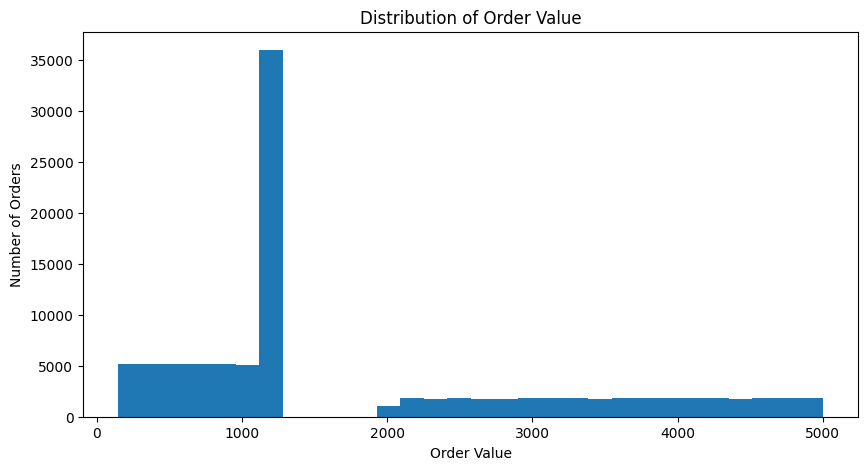

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(df['Order_Value'], bins=30)

plt.title('Distribution of Order Value')
plt.xlabel('Order Value')
plt.ylabel('Number of Orders')

plt.show()

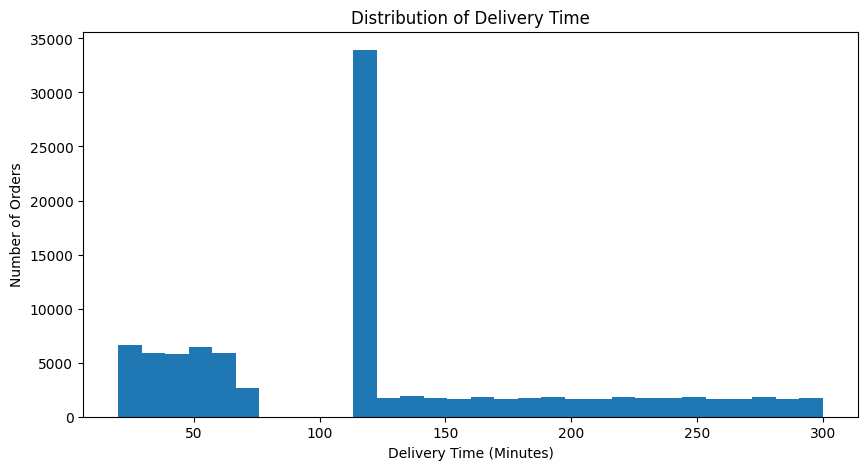

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(df['Delivery_Time_Min'], bins=30)

plt.title('Distribution of Delivery Time')
plt.xlabel('Delivery Time (Minutes)')
plt.ylabel('Number of Orders')

plt.show()

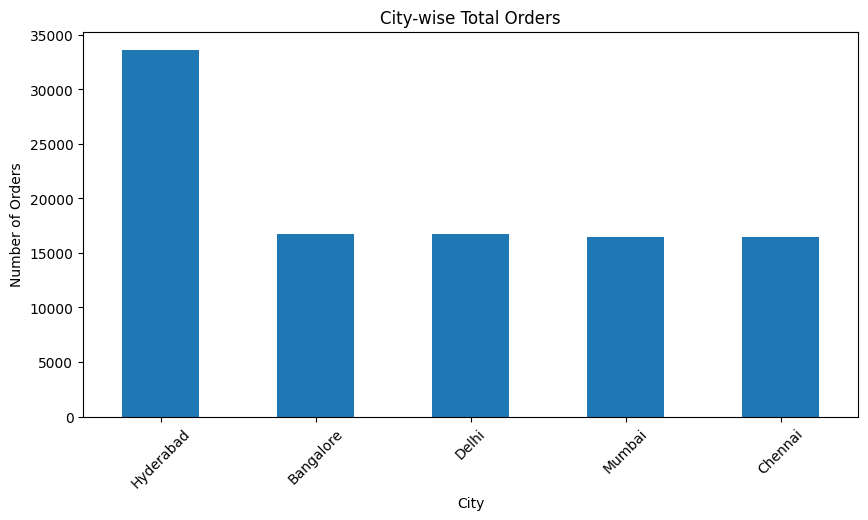

In [ ]:
city_orders = df['City'].value_counts()

plt.figure(figsize=(10, 5))

city_orders.plot(kind='bar')

plt.title('City-wise Total Orders')
plt.xlabel('City')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)

plt.show()

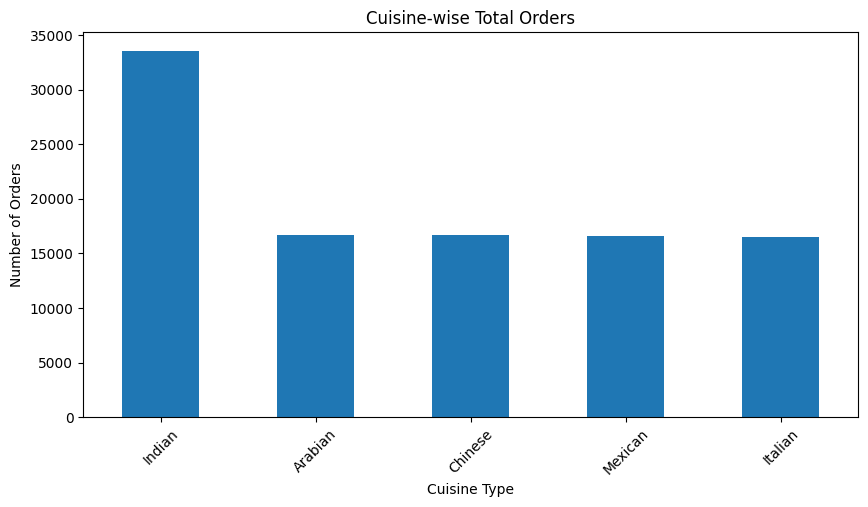

In [ ]:
cuisine_orders = df['Cuisine_Type'].value_counts()

plt.figure(figsize=(10, 5))

cuisine_orders.plot(kind='bar')

plt.title('Cuisine-wise Total Orders')
plt.xlabel('Cuisine Type')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)

plt.show()

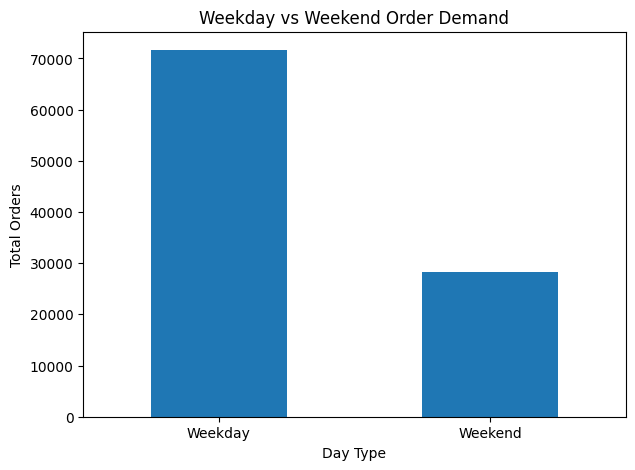

In [ ]:
day_orders = df['Order_Day_Type'].value_counts()

plt.figure(figsize=(7, 5))

day_orders.plot(kind='bar')

plt.title('Weekday vs Weekend Order Demand')
plt.xlabel('Day Type')
plt.ylabel('Total Orders')
plt.xticks(rotation=0)

plt.show()

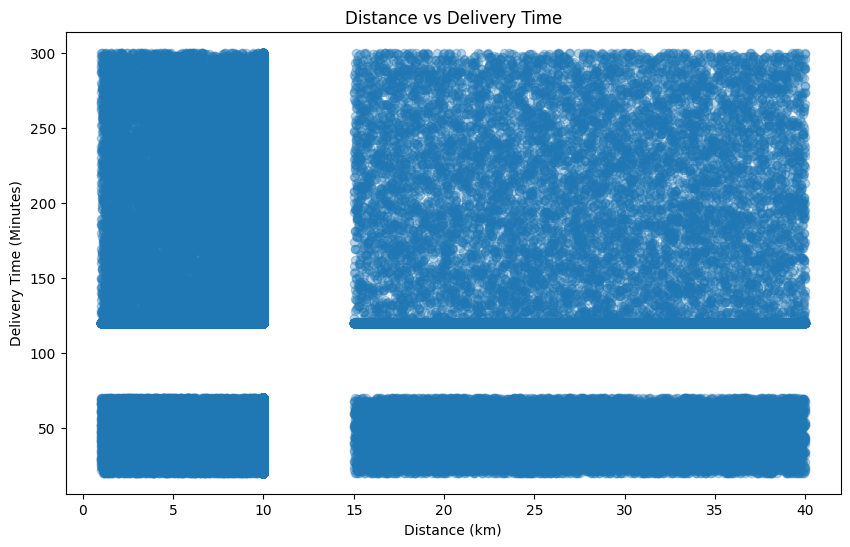

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['Distance_km'],
    df['Delivery_Time_Min'],
    alpha=0.3
)

plt.title('Distance vs Delivery Time')
plt.xlabel('Distance (km)')
plt.ylabel('Delivery Time (Minutes)')

plt.show()

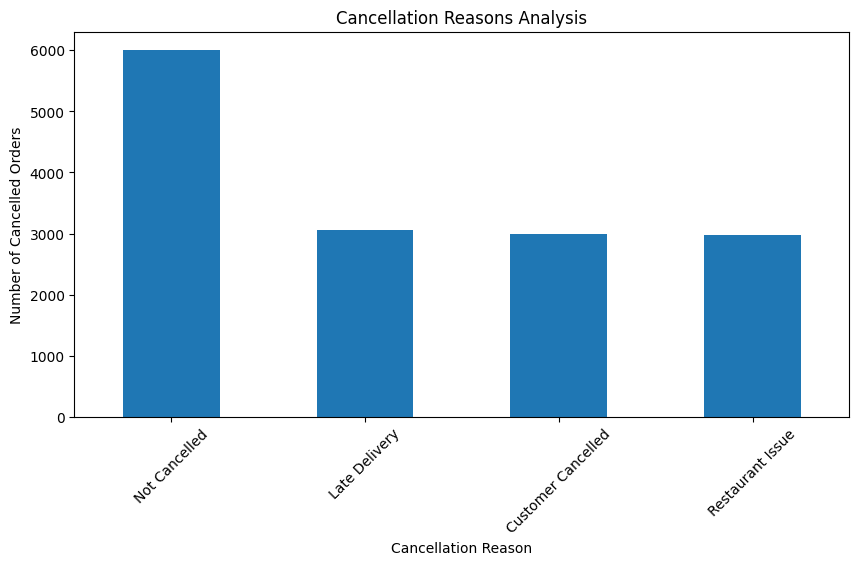

In [ ]:
cancel_reason_counts = (
    df[df['Order_Status'] == 'Cancelled']
    ['Cancellation_Reason']
    .value_counts()
)

plt.figure(figsize=(10, 5))

cancel_reason_counts.plot(kind='bar')

plt.title('Cancellation Reasons Analysis')
plt.xlabel('Cancellation Reason')
plt.ylabel('Number of Cancelled Orders')
plt.xticks(rotation=45)

plt.show()

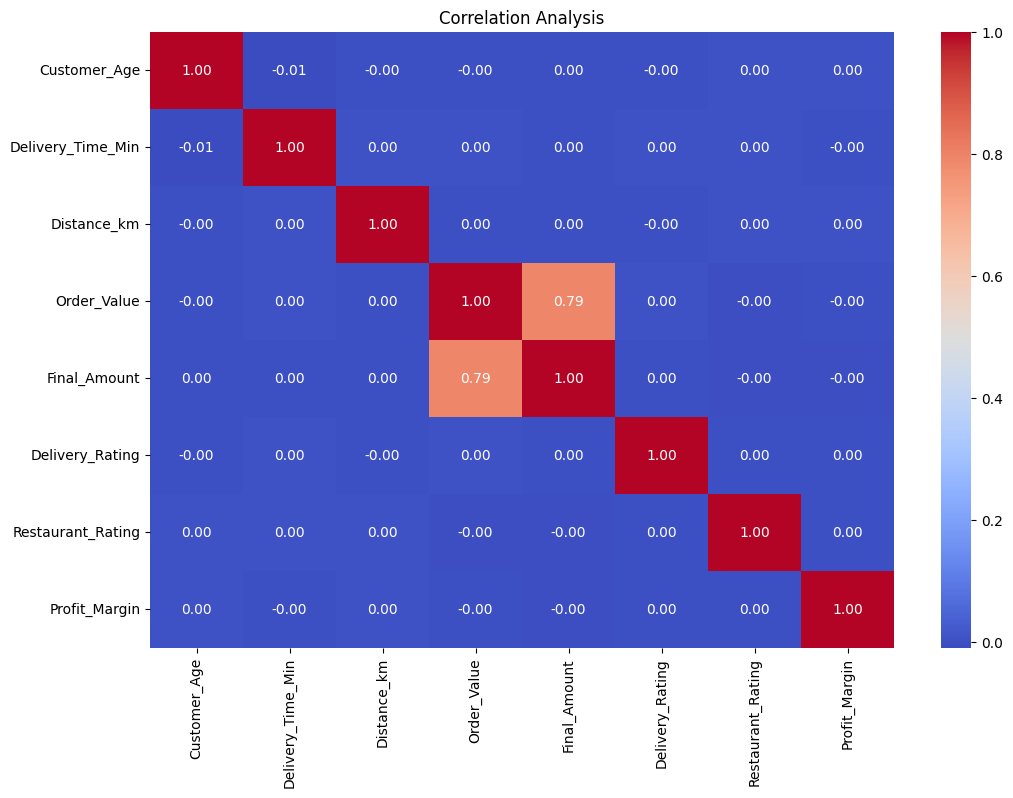

In [ ]:
import seaborn as sns

numeric_data = df.select_dtypes(include=['number'])

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Analysis')
plt.show()

In [ ]:
import os

print("app.py exists:", os.path.exists("/content/app.py"))
print("CSV exists:", os.path.exists("/content/ONLINE_FOOD_DELIVERY_CLEANED.csv"))

app.py exists: True
CSV exists: True


In [ ]:
!pkill -f streamlit || true

!streamlit run /content/app.py --server.port 8501 > /content/streamlit.log 2>&1 &

^C


In [ ]:
from google.colab import output

output.serve_kernel_port_as_window(8501)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [ ]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
!cat /content/streamlit.log



2026-09-09 15:59:15.214 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.81.64.44:8501



In [ ]:
from google.colab import output

url = output.eval_js("google.colab.kernel.proxyPort(8501)")
print(url)

https://8501-m-s-kkb-ase1a2-13kggjvcz28x8-a.asia-east1-2.prod.colab.dev


In [ ]:
!pkill -f streamlit || true

!streamlit run /content/app.py --server.port 8501 > /content/streamlit.log 2>&1 &

^C


In [ ]:
from google.colab import output

url = output.eval_js("google.colab.kernel.proxyPort(8501)")
print(url)

https://8501-m-s-kkb-ase1a2-13kggjvcz28x8-a.asia-east1-2.prod.colab.dev


In [ ]:
!curl -I http://127.0.0.1:8501

HTTP/1.1 200 OK
date: Wed, 09 Sep 2026 16:03:19 GMT
server: uvicorn
content-type: text/html; charset=utf-8
accept-ranges: bytes
content-length: 7459
last-modified: Wed, 09 Sep 2026 15:46:40 GMT
etag: "f9fc54435f0779ba892bf1e9bdcb4084"
cache-control: no-cache



In [ ]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O /content/cloudflared
!chmod +x /content/cloudflared

In [ ]:
!pkill -f cloudflared || true
!/content/cloudflared tunnel --url http://localhost:8501 2>&1 | tee /content/cloudflare.log

^C
2026-09-09T16:04:48Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-09-09T16:04:48Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-09-09T16:04:58Z INF +--------------------------------------------------------------------------------------------+
2026-09-09T16:04:58Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-09-09T16:04:58Z INF |  https://routines-raymond-rock-structured.trycloudf